In [2]:
import scanpy as sc 
import squidpy as sq
import numpy as numpy 
import torch

/opt/homebrew/Caskroom/miniconda/base/envs/spatial-tx/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/spatial-tx/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/opt/homebrew/Caskroom/miniconda/base/envs/spatial-tx/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.r

In [ ]:
#load spatial data from visium
adata_sp = sq.datasets.visium_hne_adata()

  0%|          | 0.00/314M [00:00<?, ?B/s]

In [ ]:
adata_sp.shape
adata_sp.obsm
# 2688 spots x 18078 genes
print(adata_sp.shape)
print(type(adata_sp.X))

(2688, 18078)
<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
adata_sc = sq.datasets.sc_mouse_cortex()

  0%|          | 0.00/3.03G [00:00<?, ?B/s]

AxisArrays with keys: X_pca, X_umap

In [13]:
print(adata_sc.shape)
print(adata_sc.obs.columns.tolist())


(21697, 36826)
['sample_name', 'organism', 'donor_sex', 'cell_class', 'cell_subclass', 'cell_cluster', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts']


In [ ]:
import pandas as pd

# Use raw counts as starting point (both datasets store raw counts in .raw)
adata_sc_raw = adata_sc.raw.to_adata()
adata_sp_raw = adata_sp.raw.to_adata()

# Find shared genes
shared_genes = list(set(adata_sc_raw.var_names) & set(adata_sp_raw.var_names))
print(f"Shared genes: {len(shared_genes)}")

# Subset to shared genes
adata_sc_shared = adata_sc_raw[:, shared_genes].copy()
adata_sp_shared = adata_sp_raw[:, shared_genes].copy()

# Copy cell type labels
adata_sc_shared.obs = adata_sc.obs.copy()

# Normalize from raw counts
sc.pp.normalize_total(adata_sc_shared, target_sum=1e4)
sc.pp.log1p(adata_sc_shared)
sc.pp.normalize_total(adata_sp_shared, target_sum=1e4)
sc.pp.log1p(adata_sp_shared)

# Paper approach: union of top 100 marker genes per cell type as training signal
cell_type_col = 'cell_subclass'
sc.tl.rank_genes_groups(adata_sc_shared, groupby=cell_type_col, method='wilcoxon', n_genes=100)
marker_df = sc.get.rank_genes_groups_df(adata_sc_shared, group=None)
training_genes = marker_df['names'].unique().tolist()
training_genes = [g for g in training_genes if g in adata_sp_shared.var_names]
print(f"Training genes (marker-based): {len(training_genes)}")
print(f"Cell types: {adata_sc_shared.obs[cell_type_col].nunique()}")

In [ ]:
import torch.nn.functional as F
import numpy as np

# Use MPS
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

def to_dense(X):
    return X.toarray() if hasattr(X, 'toarray') else np.array(X)

S_train = torch.tensor(to_dense(adata_sc_shared[:, training_genes].X), dtype=torch.float32).to(device)  # (n_cells, n_train_genes)
T_train = torch.tensor(to_dense(adata_sp_shared[:, training_genes].X), dtype=torch.float32).to(device)  # (n_spots, n_train_genes)

n_cells = S_train.shape[0]
n_spots = T_train.shape[0]

print(f"S_train (scRNA-seq): {S_train.shape}")
print(f"T_train (spatial):   {T_train.shape}")
print(f"M will be:           ({n_cells}, {n_spots})")

Using device: mps
S_train (scRNA-seq): torch.Size([21697, 1519])
T_train (spatial):   torch.Size([2688, 1519])
M will be:           (21697, 2688)


In [ ]:
def compute_loss(M_raw, S, T):
    # Apply softmax row-wise so each cell's probabilities sum to 1
    M = F.softmax(M_raw, dim=1)  # (n_cells, n_spots)

    # Project scRNA-seq onto spots: predicted spatial expression
    S_pred = M.T @ S  # (n_spots, n_train_genes)

    # Cosine similarity: measures if gene expression patterns match (ignores scale)
    cos_sim = F.cosine_similarity(S_pred, T, dim=1).mean()

    # KL divergence: cell density across spots should be uniform
    # (prevents all cells from collapsing onto a single spot)
    density = M.sum(dim=0)                          # total cell mass per spot
    density = density / density.sum()               # normalize to distribution
    uniform = torch.ones(n_spots, device=device) / n_spots
    kl_loss = (density * (torch.log(density + 1e-8) - torch.log(uniform))).sum()

    # Maximize cosine similarity, minimize KL divergence
    return -cos_sim + kl_loss

# Learnable mapping matrix (raw logits, softmax applied inside loss)
M_raw = torch.nn.Parameter(torch.zeros(n_cells, n_spots, device=device))
optimizer = torch.optim.Adam([M_raw], lr=0.1)

In [18]:
# Training loop
n_iters = 1000

for i in range(n_iters):
    optimizer.zero_grad()
    loss = compute_loss(M_raw, S_train, T_train)
    loss.backward()
    optimizer.step()

    if i % 100 == 0:
        print(f"Iter {i:4d} | Loss: {loss.item():.4f}")

print("Training complete!")

Iter    0 | Loss: -0.7747
Iter  100 | Loss: -0.7830
Iter  200 | Loss: -0.7877
Iter  300 | Loss: -0.7922
Iter  400 | Loss: -0.7955
Iter  500 | Loss: -0.7975
Iter  600 | Loss: -0.7986
Iter  700 | Loss: -0.7990
Iter  800 | Loss: -0.7993
Iter  900 | Loss: -0.7994
Training complete!


In [19]:
import anndata

# Get final mapping matrix
with torch.no_grad():
    M = F.softmax(M_raw, dim=1)  # (n_cells, n_spots)

# Project all shared genes (not just training genes) onto spatial coordinates
S_all = torch.tensor(to_dense(adata_sc_shared.X), dtype=torch.float32).to(device)
imputed = (M.T @ S_all).cpu().numpy()  # (n_spots, n_shared_genes)
print(f"Imputed expression shape: {imputed.shape}")

# Build a new AnnData with imputed spatial expression
adata_imputed = anndata.AnnData(X=imputed)
adata_imputed.obs_names = adata_sp.obs_names
adata_imputed.var_names = adata_sc_shared.var_names
adata_imputed.obs = adata_sp.obs.copy()
adata_imputed.obsm['spatial'] = adata_sp.obsm['spatial']

Imputed expression shape: (2688, 16311)


/var/folders/fz/yyjmfcln0qg_xl49_bp8ycvr0000gn/T/ipykernel_1365/2301275544.py:27: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sp, color='predicted_cell_type', spot_size=150,


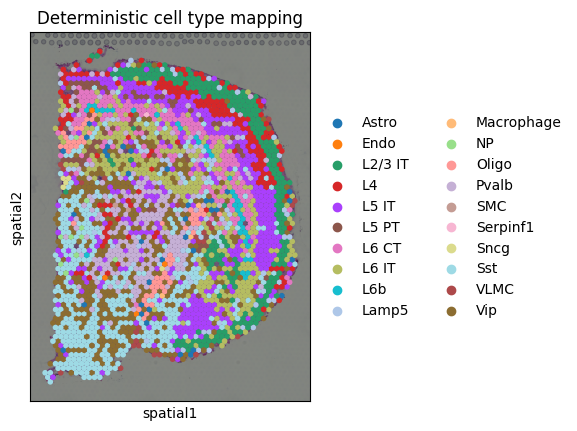

/var/folders/fz/yyjmfcln0qg_xl49_bp8ycvr0000gn/T/ipykernel_1365/2301275544.py:32: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed, color=gene, spot_size=150, title=f'Imputed: {gene}')


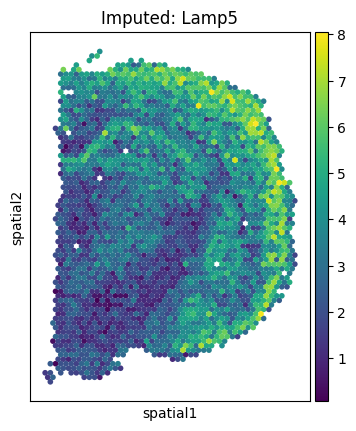

In [ ]:
import matplotlib.pyplot as plt

# --- Probabilistic cell type mapping (Figure 2a style from paper) ---
# Sum mapping probabilities per cell type to get per-spot cell type distribution
cell_types = adata_sc.obs[cell_type_col].values
unique_types = np.unique(cell_types)

with torch.no_grad():
    M_np = F.softmax(M_raw, dim=1).cpu().numpy()  # (n_cells, n_spots)

# Build (n_spots x n_cell_types) probability matrix
cell_type_probs = np.zeros((n_spots, len(unique_types)))
for j, ct in enumerate(unique_types):
    mask = cell_types == ct
    cell_type_probs[:, j] = M_np[mask, :].sum(axis=0)

# Normalize per spot
cell_type_probs = cell_type_probs / (cell_type_probs.sum(axis=1, keepdims=True) + 1e-8)

# Store per-cell-type probabilities in adata_sp
for j, ct in enumerate(unique_types):
    adata_sp.obs[f'prob_{ct}'] = cell_type_probs[:, j]

#Deterministic mapping use argmax
best_type_idx = cell_type_probs.argmax(axis=1)
adata_sp.obs['predicted_cell_type'] = pd.Categorical([unique_types[i] for i in best_type_idx])
sc.pl.spatial(adata_sp, color='predicted_cell_type', spot_size=150,
              title='Deterministic cell type mapping')

# --- Gene imputation: visualize a known cortical marker (Figure 2e style) ---
gene = 'Lamp5' if 'Lamp5' in adata_imputed.var_names else adata_imputed.var_names[0]
sc.pl.spatial(adata_imputed, color=gene, spot_size=150, title=f'Imputed: {gene}')